['Age', 'Gender', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin', 'Result']
   Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   64       1          66                      160                        83   
1   21       1          94                       98                        46   
2   55       1          64                      160                        77   
3   64       1          70                      120                        55   
4   55       1          64                      112                        65   

   Blood sugar  CK-MB  Troponin    Result  
0        160.0   1.80     0.012  negative  
1        296.0   6.75     1.060  positive  
2        270.0   1.99     0.003  negative  
3        270.0  13.87     0.122  positive  
4        300.0   1.08     0.003  negative  
Accuracy: 0.8144
Confusion Matrix:
[[ 74  27]
 [ 22 141]]
Classification Report:
              precision    recall  

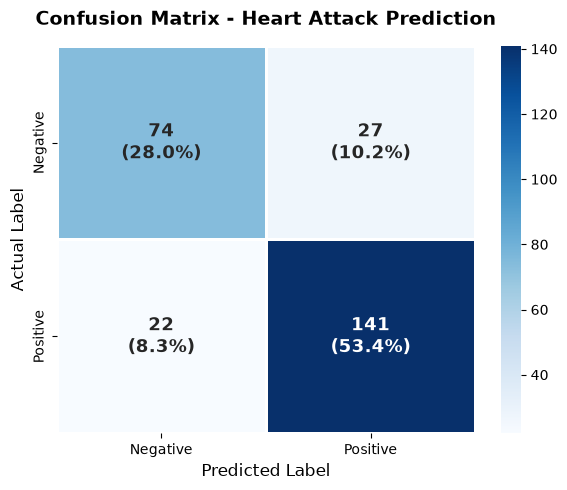

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("data/Heart attack - medical dataset.csv")
print(df.columns.tolist())  # confirm exact column names first
print(df.head())

X = df[["Age", "Heart rate", "Systolic blood pressure", "Diastolic blood pressure",
        "Blood sugar", "CK-MB", "Troponin"]]
y = df["Result"].map({"positive": 1, "negative": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum() * 100

labels = np.array(
    [f"{val}\n({pct:.1f}%)" for val, pct in zip(cm.flatten(), cm_percent.flatten())]
).reshape(2, 2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
            cbar=True, linewidths=1, linecolor="white",
            annot_kws={"size": 13, "weight": "bold"})

plt.title("Confusion Matrix - Heart Attack Prediction", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()